# Create 3-scale template and dataset (coarsest 2000 m mesh removed)

Full pipeline for the **coarse-mesh ablation**: same as `create_dataset_100m.ipynb` but with
the coarsest gmsh level deleted.

Scales: SFINCS 100 m (finest, index 0) + gmsh 500 m + gmsh 1000 m (new coarsest / U-Net bottom).

Expected output:
```
database/datasets/train/template_100m_3scales.pkl
database/datasets/train/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales.pkl
database/datasets/test/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales.pkl
```

Training config: `config_best_sweep_3scales.yaml` (K adapted from `[1,1,1,5,4,3,2]` to `[1,1,5,3,2]`).
Script equivalents (used by the hal8 auto-build): `build_template_3scales.py` + `run_convert_warmstart_3scales.py`.

In [1]:
import os, sys

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print('Repo root:', REPO_ROOT)

Repo root: C:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Config

In [2]:
# Template output path
TEMPLATE_PKL = 'database/datasets/train/template_100m_3scales.pkl'

# Non-warmstart simulation folder: provides the template geometry
# (boundary polygon, DEM) and the SFINCS grid used as the finest mesh level
SFINCS_DIR = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon'
)
SFINCS_MAP_TEMPLATE = f'{SFINCS_DIR}/sfincs_map.nc'
SHAPEFILE           = f'{SFINCS_DIR}/gis/region.geojson'
DEM_TIF             = f'{SFINCS_DIR}/gis/dep.tif'

# Coarse gmsh resolutions [m] — 2 levels only (2000 m deleted vs the 4-scale template)
MESH_RESOLUTIONS = [1000, 500]
NUM_SCALES       = 3          # SFINCS 100 m + the two gmsh levels above

# Simulations to convert — each tuple: (sfincs_dir, dataset_name, out_split)
SFINCS_DIR_WARMSTART = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart'
)

simulations = [
    # Main training/eval dataset — from the (re-run, 6-day-spinup) warmstart simulation
    (SFINCS_DIR_WARMSTART, 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales', 'train'),
    (SFINCS_DIR_WARMSTART, 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales', 'test'),
]

OUT_ROOT = 'database/datasets'

# SFINCS variable names
WATER_LEVEL_VAR = 'zs'
BED_LEVEL_VAR   = 'zb'
VX_VAR = 'u'   # set to None if not present
VY_VAR = 'v'   # set to None if not present

# Force flags
FORCE_REBUILD_TEMPLATE = False   # set True to recreate template from scratch
FORCE_REBUILD_PKL      = False   # set True to recreate dataset pkls

## Step 1 — Create template

In [3]:
from database.create_mesh_template_marg import create_mesh_template_pkl

if FORCE_REBUILD_TEMPLATE and os.path.exists(TEMPLATE_PKL):
    os.remove(TEMPLATE_PKL)
    print('Deleted stale template:', TEMPLATE_PKL)

if os.path.exists(TEMPLATE_PKL):
    print('Template already exists:', TEMPLATE_PKL)
    print('Set FORCE_REBUILD_TEMPLATE = True to recreate.')
else:
    create_mesh_template_pkl(
        shapefile_path        = SHAPEFILE,
        dem_tif_path          = DEM_TIF,
        output_pkl_path       = TEMPLATE_PKL,
        with_multiscale       = True,
        number_of_multiscales = NUM_SCALES,
        mesh_resolutions      = MESH_RESOLUTIONS,
        sfincs_map_nc         = SFINCS_MAP_TEMPLATE,
    )
    print('Template saved:', TEMPLATE_PKL)

Template already exists: database/datasets/train/template_100m_3scales.pkl
Set FORCE_REBUILD_TEMPLATE = True to recreate.


## Step 2 — Inspect template (scales + node counts)

num_meshes: 3   (expected 3)
node_ptr:   [0, 25081, 28799, 29802]
edge_ptr:   [0, 98735, 109622, 112497]


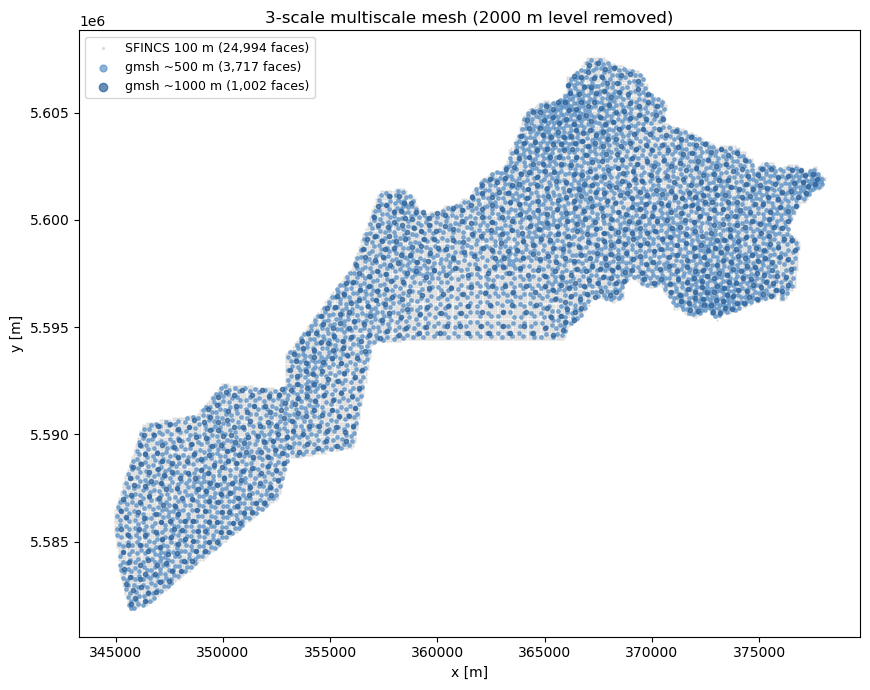

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(TEMPLATE_PKL, 'rb') as f:
    template_data = pickle.load(f)[0]

meshes = template_data.mesh.meshes   # [0] = SFINCS (finest), [1..] = gmsh coarser
print(f'num_meshes: {template_data.mesh.num_meshes}   (expected {NUM_SCALES})')
print(f'node_ptr:   {template_data.node_ptr.tolist()}')
print(f'edge_ptr:   {template_data.edge_ptr.tolist()}')

scale_names = ['SFINCS 100 m', 'gmsh ~500 m', 'gmsh ~1000 m']
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#d4d4d4', '#5d93c7', '#2a6099']
sizes  = [0.5, 6, 9]
for i, m in enumerate(meshes):
    xy = np.asarray(m.face_xy)
    n_gc = len(m.ghost_cells_ids) if hasattr(m, 'ghost_cells_ids') else 0
    n_reg = xy.shape[0] - n_gc
    label = f'{scale_names[i] if i < len(scale_names) else f"scale {i}"} ({n_reg:,} faces)'
    ax.scatter(xy[:n_reg, 0], xy[:n_reg, 1], s=sizes[min(i, 2)], c=colors[min(i, 2)],
               alpha=0.7, label=label, rasterized=True)
ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('3-scale multiscale mesh (2000 m level removed)')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

## Step 3 — Create dataset pkl files

In [5]:
import copy
import torch
import xarray as xr

from database.convert_sfincs_to_pkl_marg import (
    load_single_data_object,
    get_target_points,
    get_source_points,
    interpolate_time_series,
    parse_src_file,
    parse_dis_file,
    build_output_data,
)

print('Loading template...')
template_data = load_single_data_object(TEMPLATE_PKL)
target_points = get_target_points(template_data)
print('  Template mesh faces:', target_points.shape[0])

# Grid coordinates from the non-warmstart file (2D x/y, same grid as warmstart)
ds_grid = xr.open_dataset(SFINCS_MAP_TEMPLATE, decode_times=False)
source_points = get_source_points(ds_grid)
ds_grid.close()
print('  Source points:', source_points.shape[0])

for sfincs_dir, dataset_name, out_split in simulations:
    out_path = os.path.join(OUT_ROOT, out_split, dataset_name + '.pkl')
    if not FORCE_REBUILD_PKL and os.path.exists(out_path):
        print('Skipping (already exists):', out_path)
        continue

    sfincs_map = os.path.join(sfincs_dir, 'sfincs_map.nc')
    src_file   = os.path.join(sfincs_dir, 'sfincs.src')
    dis_file   = os.path.join(sfincs_dir, 'sfincs.dis')

    print()
    print('Processing:', dataset_name, '->', out_split)
    ds = xr.open_dataset(sfincs_map, decode_times=False)

    zs = ds[WATER_LEVEL_VAR].values
    zb = ds[BED_LEVEL_VAR].values
    # SFINCS writes zs=NaN for DRY cells. Fill them with the bed level so they enter
    # the interpolation as WD=0. Without this, interpolate_time_series drops the NaNs
    # and linearly interpolates between wet cells only, smearing phantom water across
    # every dry area that lies between wet river branches (~15k fake wet cells).
    zs_filled = np.where(np.isnan(zs), zb[None, :, :], zs)
    WD_grid = np.maximum(zs_filled - zb[None, :, :], 0.0).astype(np.float32)
    print('  Interpolating WD...')
    WD = interpolate_time_series(source_points, WD_grid, target_points, 'WD')

    ds_raw = xr.open_dataset(sfincs_map, decode_times=False, mask_and_scale=False)
    if VX_VAR and VX_VAR in ds.data_vars:
        VX_raw = ds_raw[VX_VAR].values.astype(np.float32)
        fv = ds_raw[VX_VAR].attrs.get('_FillValue', None)
        if fv is not None:
            VX_raw[VX_raw == fv] = np.nan
        print('  Interpolating VX...')
        VX = interpolate_time_series(source_points, VX_raw, target_points, 'VX')
    else:
        VX = np.zeros_like(WD)
    if VY_VAR and VY_VAR in ds.data_vars:
        VY_raw = ds_raw[VY_VAR].values.astype(np.float32)
        fv = ds_raw[VY_VAR].attrs.get('_FillValue', None)
        if fv is not None:
            VY_raw[VY_raw == fv] = np.nan
        print('  Interpolating VY...')
        VY = interpolate_time_series(source_points, VY_raw, target_points, 'VY')
    else:
        VY = np.zeros_like(WD)
    ds_raw.close()

    time_var = ds.coords.get('time', ds.coords.get('t', None))
    map_times_s = (time_var.values.astype(np.float64) if time_var is not None
                   else np.arange(zs.shape[0]) * 3600.0)
    ds.close()

    print('  Reading src/dis files...')
    src_xy = parse_src_file(src_file)
    dis_times_s, discharge = parse_dis_file(dis_file)
    print(' ', len(src_xy), 'source points, discharge shape:', discharge.shape)

    data_out = build_output_data(
        template_data, WD=WD, VX=VX, VY=VY,
        map_times_s=map_times_s, src_xy=src_xy,
        dis_times_s=dis_times_s, discharge=discharge,
    )

    os.makedirs(os.path.join(OUT_ROOT, out_split), exist_ok=True)
    with open(out_path, 'wb') as f:
        pickle.dump([data_out], f)
    print('  Saved:', out_path)
    print('  WD=', tuple(data_out.WD.shape),
          '| node_BC=', data_out.node_BC.tolist(),
          '| BC=', tuple(data_out.BC.shape))

    # Sanity check: wet-cell count at finest scale must match the SFINCS map (~1k-2.5k, not ~15k)
    np_ptr = data_out.node_ptr.numpy()
    wd_s0 = data_out.WD[np_ptr[0]:np_ptr[1]].numpy()
    wet = (wd_s0 > 0.05).sum(0)
    print(f'  wet cells @0.05m: t=0 {wet[0]}  peak {wet.max()} (t={wet.argmax()})  t=-1 {wet[-1]}')

Loading template...
  Template mesh faces: 29802
  Source points: 85656
Skipping (already exists): database/datasets\train\ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales.pkl
Skipping (already exists): database/datasets\test\ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales.pkl


## Step 4 — Sanity check vs the 4-scale dataset

In [6]:
# The finest (SFINCS) scale is identical in the 3- and 4-scale datasets, so the
# wet-cell trajectory and the BC must match exactly. Reference (new GT, Jul 4):
# wet cells @0.05m: t=0 974  peak 2474 (t=77)  t=-1 1822
REFERENCE_PKL = 'database/datasets/train/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart.pkl'

with open('database/datasets/train/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_3scales.pkl', 'rb') as f:
    d3 = pickle.load(f)[0]

print('num_meshes:', d3.mesh.num_meshes, ' (expected 3)')
print('node_ptr:  ', d3.node_ptr.tolist())
print('node_BC:   ', d3.node_BC.tolist())
print('type_BC:   ', int(d3.type_BC), ' (2 = discharge -> VX slot)')
print('Q peak:    ', d3.BC[:, :, 1].max().item(), 'm^3/s')

ptr3 = d3.node_ptr.numpy()
wd3 = d3.WD[ptr3[0]:ptr3[1]].numpy()
wet3 = (wd3 > 0.05).sum(0)
print(f'wet cells @0.05m: t=0 {wet3[0]}  peak {wet3.max()} (t={wet3.argmax()})  t=-1 {wet3[-1]}')

if os.path.exists(REFERENCE_PKL):
    with open(REFERENCE_PKL, 'rb') as f:
        d4 = pickle.load(f)[0]
    ptr4 = d4.node_ptr.numpy()
    wd4 = d4.WD[ptr4[0]:ptr4[1]].numpy()
    n = min(wd3.shape[0], wd4.shape[0])
    same = np.allclose(wd3[:n], wd4[:n], atol=1e-6)
    print(f'\nFinest-scale WD identical to 4-scale dataset ({n} shared faces): {same}')
    same_bc = torch.allclose(d3.BC, d4.BC) and d3.node_BC.tolist() == d4.node_BC.tolist()
    print(f'BC identical to 4-scale dataset: {same_bc}')
else:
    print('\n(4-scale reference pkl not found — skipped comparison)')

num_meshes: 3  (expected 3)
node_ptr:   [0, 25081, 28799, 29802]
node_BC:    [12555, 7287, 15, 368, 5453, 3676, 6427]
type_BC:    2  (2 = discharge -> VX slot)
Q peak:     450.0 m^3/s
wet cells @0.05m: t=0 974  peak 2474 (t=77)  t=-1 1822

Finest-scale WD identical to 4-scale dataset (25081 shared faces): True
BC identical to 4-scale dataset: True
